## Goals for this project
This project intends to identify the macro regime the US market is operating under based on features, such as the monthly S&P 500 returns, FED rate, inflation and other features we are testing out.

## Objective 
This project uses k-means clustering on U.S. macro data (FRED + S&P 500) to identify macroeconomic regimes empirically, without imposing labels in advance. The goal is to test whether unsupervised learning can recover economically meaningful structure from raw data — and to interpret the findings using macroeconomic theory.

Testing whether macro regime awareness improves portfolio resilience.

### Robustness
A key limitation of this project is the inherrent correlation between several of these macroeconomic factors, such as inflation rate and FED rate, which leads to these factors being over-accounted for when clustering the data points. As a robustness check I run PCA to orthogonalize the features and run the clustering again.....

.. use sticky cpi for robustness check

#### Robustness Check: PCA

Steps:

- pull data, ensure everything is monthly
- transform
- standardise data
- optionally smooth the data
- choose k
- run k means
- do extensions



In [111]:
from fredapi import Fred
import yfinance as yf
import pandas as pd
import numpy as np

fred = Fred(api_key='12305d08ecfe92af03a23c0b1e8629f9')

# relevant time series data points
fed_funds = fred.get_series('FEDFUNDS')
cpi = fred.get_series('CPIAUCSL')
# sticky cpi is calculated from a subset of goods and services included in the CPI that change price relatively infrequently
# incorporates expectations about future inflation to a greater degree
sticky_cpi = fred.get_series('CORESTICKM159SFRBATL')
unemployment_rate= fred.get_series('UNRATE')
# 10 yr 2 yr yield inversion
ten_yr_yield = fred.get_series('GS10')
two_yr_yield = fred.get_series('GS2')
credit_spread = fred.get_series('BAA10Y') 
# real rates?
# volatility risk premium (implied - realized)
# implied vol
vix = fred.get_series('VIXCLS')
# realized vol calculation
sp500_daily = yf.download('^GSPC', start='1990-01-01')
# industrial production
indust_prod = fred.get_series('INDPRO')
# dollar strength
dollar_strength = yf.download('DX-Y.NYB', start = '1990-01-01')['Close']


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [112]:
# extract level 0, removing ticker names (level 1)
sp500_daily.columns = sp500_daily.columns.get_level_values(0)
sp500_close = sp500_daily['Close']

# find the daily volatility within a month and annualise
daily_returns = sp500_close.pct_change()
realized_vol = daily_returns.resample('ME').std() * (252**0.5)

realized_vol.name = 'realized_vol'

print(realized_vol.head())
print(type(realized_vol))

Date
1990-01-31    0.166852
1990-02-28    0.118577
1990-03-31    0.109818
1990-04-30    0.111118
1990-05-31    0.109765
Freq: ME, Name: realized_vol, dtype: float64
<class 'pandas.Series'>


In [113]:
# making vix a monthly data point. Vix is already annualised 
vix_monthly = vix.resample('ME').mean()
# calculate the spread
vol_risk_premium = vix_monthly - realized_vol
vol_risk_premium.name = 'vol_risk_premium'

vol_risk_premium.head()

1990-01-31    23.180421
1990-02-28    23.144055
1990-03-31    19.952455
1990-04-30    21.292382
1990-05-31    17.987962
Freq: ME, Name: vol_risk_premium, dtype: float64

In [114]:
# checking for null value in risk premium
print(vol_risk_premium.isna().sum())
print(vol_risk_premium.head(10)) 

0
1990-01-31    23.180421
1990-02-28    23.144055
1990-03-31    19.952455
1990-04-30    21.292382
1990-05-31    17.987962
1990-06-30    16.692075
1990-07-31    18.264999
1990-08-31    27.925913
1990-09-30    28.946653
1990-10-31    29.398820
Freq: ME, Name: vol_risk_premium, dtype: float64


 "if this month's daily vol persisted for a full year, what would annual vol be?" This is the standard convention so vol is comparable across periods and to VIX which is also annualized

 A VIX of 20 means the market expects 20% annualized vol over the next 30 days

In [115]:
# checking if missing - missing are from latest data points and before the other series began so no issues
print(real_rate.isna().sum())
print(real_rate.isna()) 
print(fed_funds.index[:5])
print(cpi.index[:5])

print(real_rate.first_valid_index())  # should be around 1954
print(real_rate.isna().sum())         # should be ~84-91, all at the start
print(real_rate['1990':].isna().sum()) # should be 0
print(real_rate[real_rate.isna()])

91
1947-01-31     True
1947-02-28     True
1947-03-31     True
1947-04-30     True
1947-05-31     True
              ...  
2025-09-30    False
2025-10-31     True
2025-11-30    False
2025-12-31    False
2026-01-31    False
Freq: ME, Length: 949, dtype: bool
DatetimeIndex(['1954-07-01', '1954-08-01', '1954-09-01', '1954-10-01',
               '1954-11-01'],
              dtype='datetime64[us]', freq=None)
DatetimeIndex(['1947-01-01', '1947-02-01', '1947-03-01', '1947-04-01',
               '1947-05-01'],
              dtype='datetime64[us]', freq=None)
1954-07-31 00:00:00
91
1
1947-01-31   NaN
1947-02-28   NaN
1947-03-31   NaN
1947-04-30   NaN
1947-05-31   NaN
              ..
1954-03-31   NaN
1954-04-30   NaN
1954-05-31   NaN
1954-06-30   NaN
2025-10-31   NaN
Length: 91, dtype: float64


In [116]:
# 10 yr 2yr treasury spread
treasury_spread = ten_yr_yield - two_yr_yield

In [117]:
# making dollar a monthly measure
dxy_monthly = dollar_strength.resample('ME').last().squeeze()
dxy_monthly.name = 'dxy'

# same for credit spread
credit_spread_monthly = credit_spread.resample('ME').last()
credit_spread_monthly.name = 'credit_spread'


### Transformation of data

Where the levels of data points have no standalone implications, we take the YoY change. Namely for these variables: CPI, INDPRO, DXY.

In [118]:
cpi_yoy = cpi.pct_change(12) * 100
indpro_yoy = indust_prod.pct_change(12) * 100
dxy_yoy = dxy_monthly.pct_change(12) * 100

In [119]:
# calculating real fed rate
real_rate = fed_funds - cpi_yoy

In [120]:
# resampling so all month end
real_rate = real_rate.resample('ME').last()
treasury_spread = treasury_spread.resample('ME').last()
unemployment_rate = unemployment_rate.resample('ME').last()
indpro_yoy = indpro_yoy.resample('ME').last()
cpi_yoy = cpi_yoy.resample('ME').last()

In [121]:
#### Justification of factors included

In [122]:
print(real_rate.index[:3])
print(vol_risk_premium.index[:3])
print(dxy_yoy.index[:3])
print(treasury_spread.index[:3])
print(credit_spread_monthly.index[:3])
print(unemployment_rate.index[:3])
print(indpro_yoy.index[:3])
print(cpi_yoy.index[:3])

DatetimeIndex(['1947-01-31', '1947-02-28', '1947-03-31'], dtype='datetime64[us]', freq='ME')
DatetimeIndex(['1990-01-31', '1990-02-28', '1990-03-31'], dtype='datetime64[us]', freq='ME')
DatetimeIndex(['1990-01-31', '1990-02-28', '1990-03-31'], dtype='datetime64[s]', name='Date', freq='ME')
DatetimeIndex(['1953-04-30', '1953-05-31', '1953-06-30'], dtype='datetime64[us]', freq='ME')
DatetimeIndex(['1986-01-31', '1986-02-28', '1986-03-31'], dtype='datetime64[us]', freq='ME')
DatetimeIndex(['1948-01-31', '1948-02-29', '1948-03-31'], dtype='datetime64[us]', freq='ME')
DatetimeIndex(['1919-01-31', '1919-02-28', '1919-03-31'], dtype='datetime64[us]', freq='ME')
DatetimeIndex(['1947-01-31', '1947-02-28', '1947-03-31'], dtype='datetime64[us]', freq='ME')


In [123]:
df = pd.DataFrame({
    'real_rate': real_rate,
    'vol_risk_premium': vol_risk_premium,
    'dxy_monthly': dxy_yoy,
    'treasury_spread': treasury_spread,
    'credit_spread': credit_spread_monthly,
    'unemployment_rate': unemployment_rate,
    'indust_prod': indpro_yoy,
    'cpi': cpi_yoy
}, index=real_rate.index)

df = df.dropna()
print(df.shape)
print(df.head())

(420, 8)
            real_rate  vol_risk_premium  dxy_monthly  treasury_spread  \
1991-01-31   1.262941         27.235833   -11.265018             0.96   
1991-02-28   0.937500         21.422928    -9.872440             0.98   
1991-03-31   1.298849         17.610429    -1.782480             1.01   
1991-04-30   1.100070         17.215027    -1.643923             1.09   
1991-05-31   0.745143         16.797287     0.161318             1.29   

            credit_spread  unemployment_rate  indust_prod       cpi  
1991-01-31           2.30                6.4    -0.961461  5.647059  
1991-02-28           2.09                6.6    -2.577958  5.312500  
1991-03-31           1.96                6.8    -3.618696  4.821151  
1991-04-30           1.83                6.7    -3.110550  4.809930  
1991-05-31           1.77                6.9    -2.494978  5.034857  


### Exploration

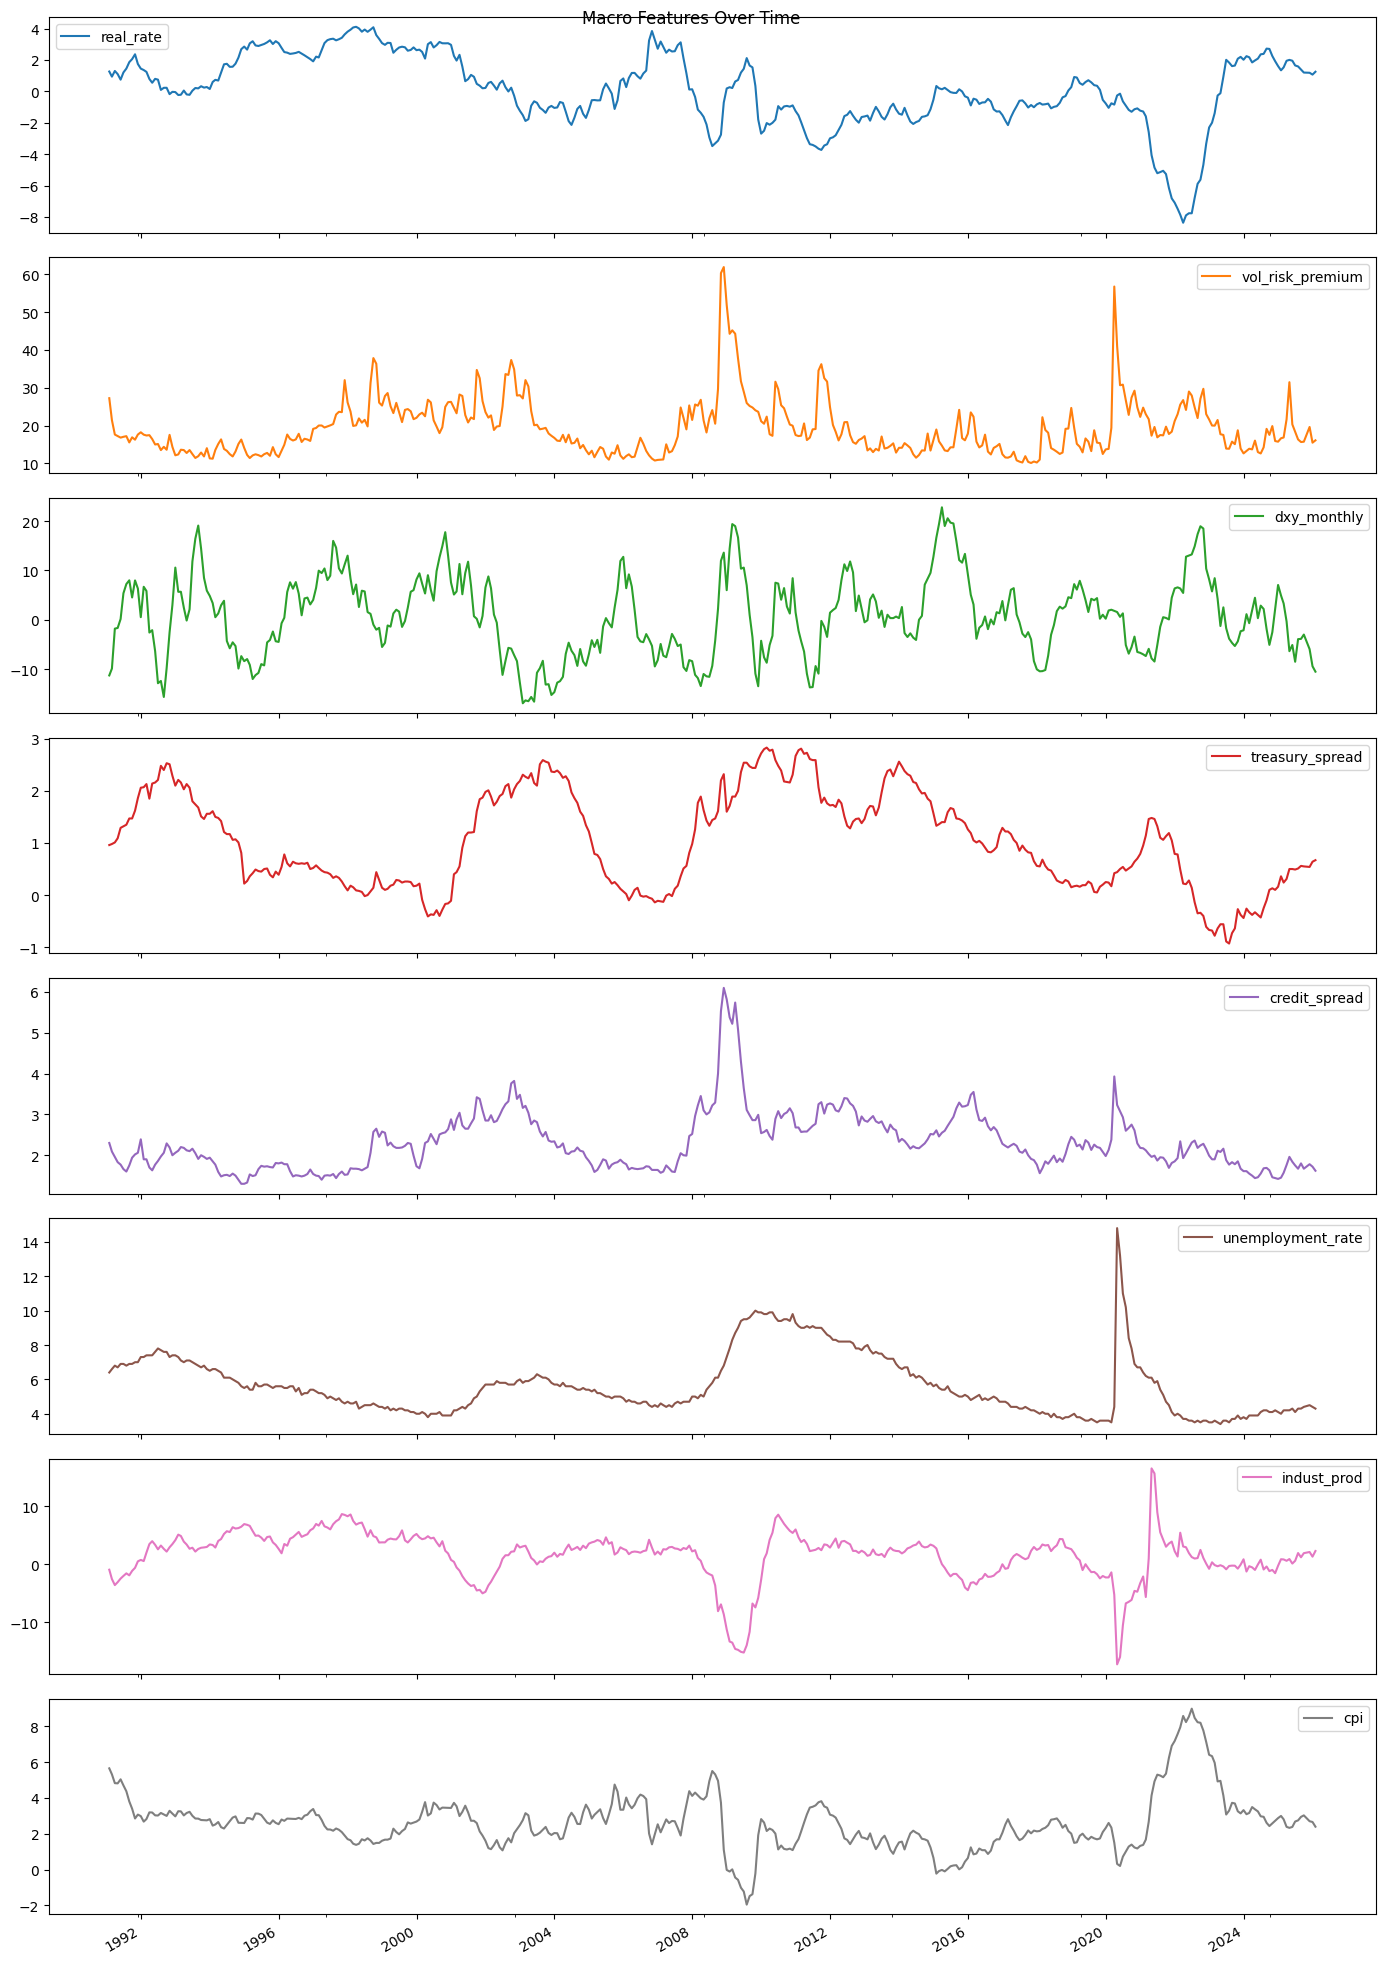

In [124]:
import matplotlib.pyplot as plt

df.plot(subplots=True, figsize=(14, 20), title='Macro Features Over Time')
plt.tight_layout()
plt.show()

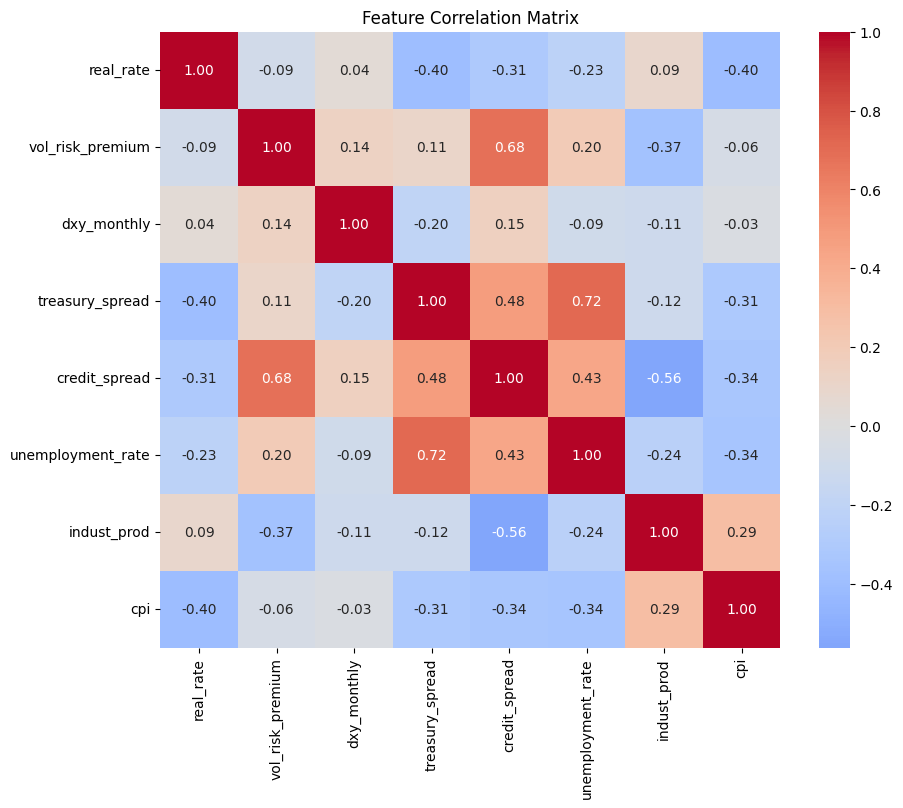

In [125]:
# checking correlation
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

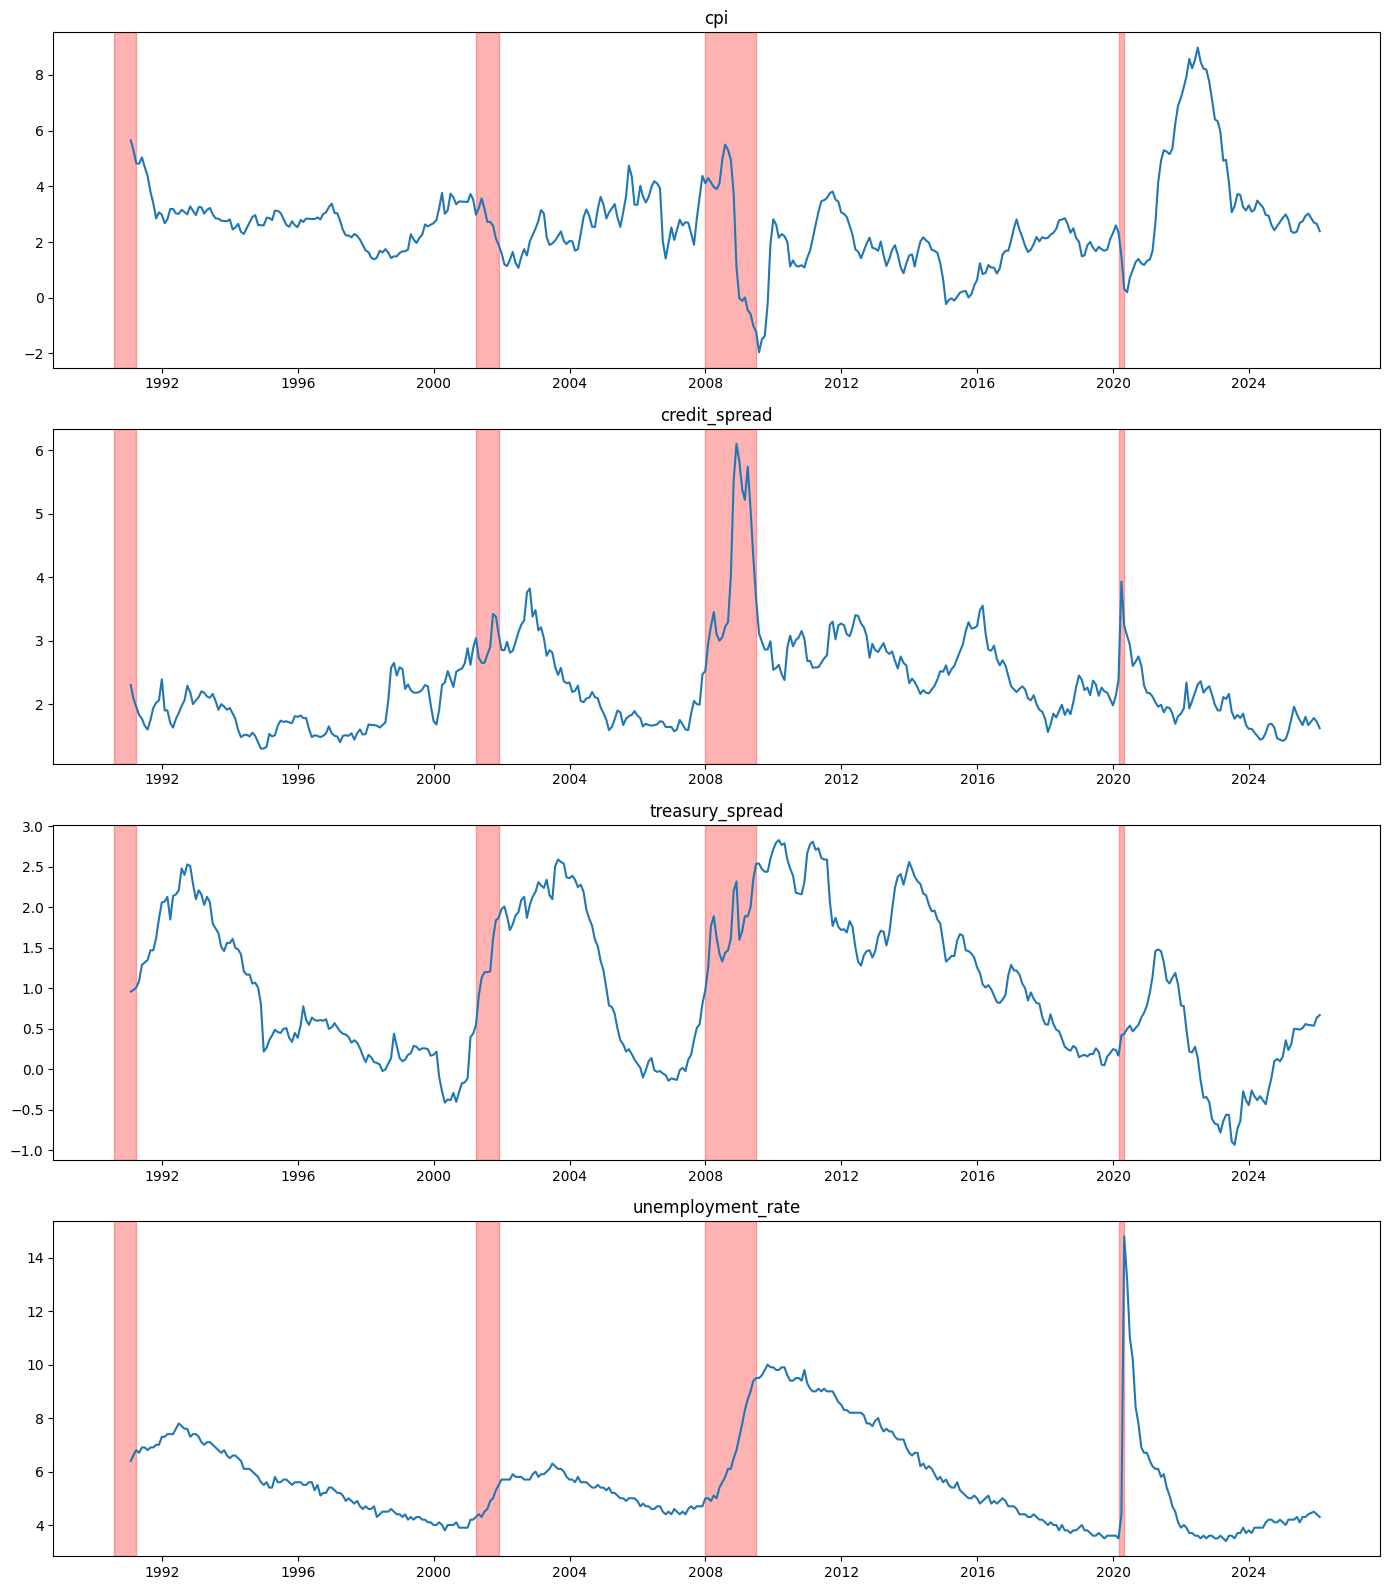

In [126]:
# NBER recession dates
recessions = [
    ('1990-07-31', '1991-03-31'),
    ('2001-03-31', '2001-11-30'),
    ('2007-12-31', '2009-06-30'),
    ('2020-02-29', '2020-04-30')
]

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
features = ['cpi', 'credit_spread', 'treasury_spread', 'unemployment_rate']

for ax, feat in zip(axes, features):
    ax.plot(df.index, df[feat])
    for start, end in recessions:
        ax.axvspan(start, end, alpha=0.3, color='red', label='Recession')
    ax.set_title(feat)
plt.tight_layout()
plt.show()

From these above, its clear that all these macroeconomic factos exhibit some anomalous behvaiour during/ after the recession. It is clear that unemployment is a lagging indicator. When the recession starts, the unemployment rate then sharply increases. On the contrar, treasury spread appears to behave as a leading indicator and exhibits a yield inversion becore recessions like 2001 and 2008 recessions. This yield inversion inidicates that the market believes monetary policy is too tight for long run growth( 2 yr is high as Fed fights inflation now but 10 yr is low due to lower expected growth and inflation). The credit spread clearly exhibits sharp spikes in recessionary environments - this is as investors become more risk averse (corporate yields rise and treasury yields fall). 

CPI behaves differently across recessions — the 2008 recession showed a dramatic spike-then-crash driven by oil, while the 2020 recession barely registered before giving way to the largest inflation surge in 30 years. This heterogeneity motivates using sticky CPI rather than headline CPI, as it filters out the transitory oil-driven spikes and captures more persistent inflationary pressure.

TODO: ADD STICKY CPI TO HAVE A LOOK AT WHAT CHANGES!!!

I use unemployment and industrial production because they capture different aspects of the growht cycle. industial pord can slow straight away whereas unemployment is a lagging indicator. key question here:  "do macro regimes — defined independently of equity returns — explain subsequent equity performance?"

std dev captures how violent the daily moves were regardless of where the month ended up overall

## Standardisation

In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)

print(df_scaled.head())
print(df_scaled.describe())

            real_rate  vol_risk_premium  dxy_monthly  treasury_spread  \
1991-01-31   0.500994          1.090540    -1.499815        -0.072749   
1991-02-28   0.360057          0.301771    -1.324652        -0.050971   
1991-03-31   0.516544         -0.215557    -0.307068        -0.018304   
1991-04-30   0.430460         -0.269211    -0.289639         0.068808   
1991-05-31   0.276754         -0.325895    -0.062570         0.286590   

            credit_spread  unemployment_rate  indust_prod       cpi  
1991-01-31      -0.005649           0.410939    -0.583632  1.959232  
1991-02-28      -0.298728           0.524413    -0.969337  1.742480  
1991-03-31      -0.480159           0.637887    -1.217663  1.424148  
1991-04-30      -0.661589           0.581150    -1.096417  1.416878  
1991-05-31      -0.745326           0.694624    -0.949538  1.562602  
        real_rate  vol_risk_premium  dxy_monthly  treasury_spread  \
count  420.000000      4.200000e+02   420.000000     4.200000e+02   
mea

### K- Means

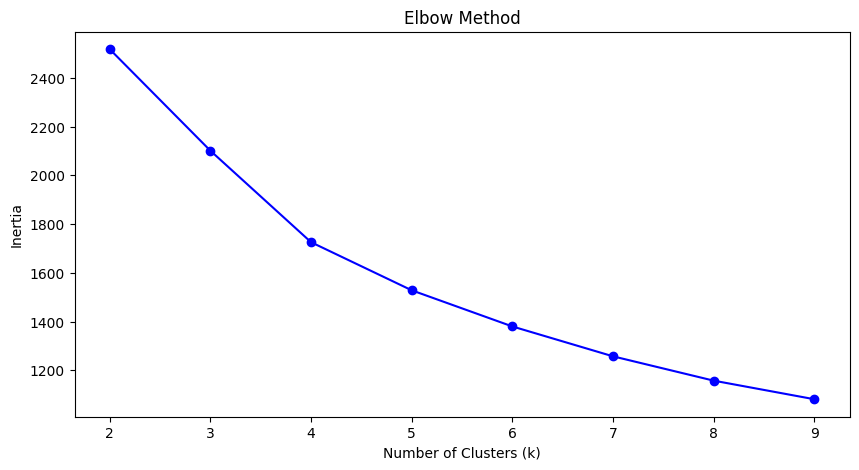

In [128]:
# looking at inertia with number of clusters: trying to find the elbow point where having additional clusters does not find real 
# distinct macro conditions and starts overfitting noise
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 10)

for k in k_range:
    # create k means object
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # will run 10 times with different random starts
    # run the k-means on the data
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    # record the final inertia

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.show()

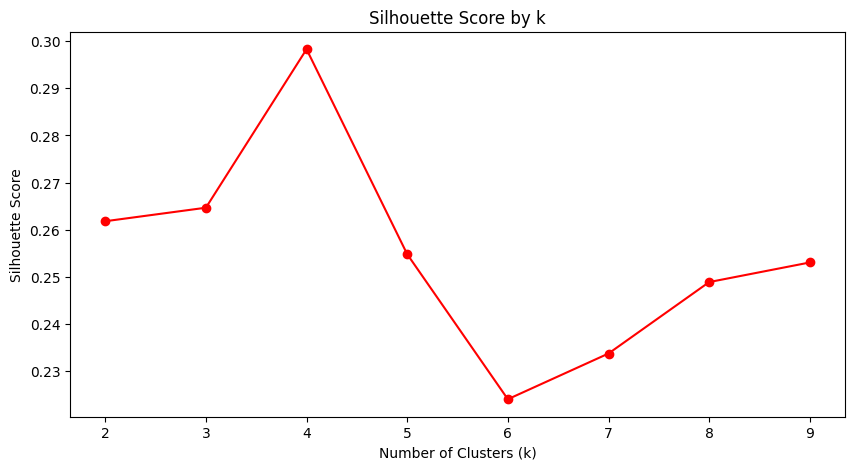

In [129]:
# Using silhouette score to determine how many clusters to use
# Silhouette score measures for each point: how similar it is to its own cluster versus the nearest other cluster
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # will run 10 times with different random starts
    labels = kmeans.fit_predict(df_scaled)
    # fit_predict fit the kmeans and then gets the predicted cluster labels (what cluster each row of data belongs to)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.xticks(k_range)
plt.show()

After looking for the elbow point and computing the silhouette scores, it appears that the K-means clustering should be run for 4 clusters and the months divide into 4 distinct macroeconomic regimes

In [130]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['regime'] = kmeans.fit_predict(df_scaled)

print(df['regime'].value_counts())

regime
1    202
0    181
3     22
2     15
Name: count, dtype: int64


In [131]:
# inspecting what months are in the regimes
print(df[df['regime'] == 2].index)
print(df[df['regime'] == 3].index)

DatetimeIndex(['2008-10-31', '2008-11-30', '2008-12-31', '2009-01-31',
               '2009-02-28', '2009-03-31', '2009-04-30', '2009-05-31',
               '2009-06-30', '2009-07-31', '2009-08-31', '2020-03-31',
               '2020-04-30', '2020-05-31', '2020-06-30'],
              dtype='datetime64[us]', freq=None)
DatetimeIndex(['2021-05-31', '2021-06-30', '2021-07-31', '2021-08-31',
               '2021-09-30', '2021-10-31', '2021-11-30', '2021-12-31',
               '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30',
               '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31',
               '2022-09-30', '2022-10-31', '2022-11-30', '2022-12-31',
               '2023-01-31', '2023-02-28'],
              dtype='datetime64[us]', freq=None)


From running k-means clustering with 4 clusters, we can see that the majority of the time, the economy is in regumes 1 and 0. However, in extreme situations, it goes to regimes 3 and 2, suggesting these months have out of the ordinary economic circumstances. We can see that these regime 2 identifies periods of economic stress/ recession, namely the 2008 crisis and Covid 2020.

Cluster 3 has identified a high inflationary regime from 2021 - 2023

In [132]:
# inspecting clusters 1 and 0
print(df[df['regime'] == 1].index)
print(df[df['regime'] == 0].index)

DatetimeIndex(['1991-01-31', '1991-02-28', '1991-03-31', '1991-04-30',
               '1991-05-31', '1991-06-30', '1991-07-31', '1991-08-31',
               '1994-03-31', '1994-04-30',
               ...
               '2025-03-31', '2025-04-30', '2025-05-31', '2025-06-30',
               '2025-07-31', '2025-08-31', '2025-09-30', '2025-11-30',
               '2025-12-31', '2026-01-31'],
              dtype='datetime64[us]', length=202, freq=None)
DatetimeIndex(['1991-09-30', '1991-10-31', '1991-11-30', '1991-12-31',
               '1992-01-31', '1992-02-29', '1992-03-31', '1992-04-30',
               '1992-05-31', '1992-06-30',
               ...
               '2020-07-31', '2020-08-31', '2020-09-30', '2020-10-31',
               '2020-11-30', '2020-12-31', '2021-01-31', '2021-02-28',
               '2021-03-31', '2021-04-30'],
              dtype='datetime64[us]', length=181, freq=None)


In [133]:
# inspecting the centroids of each cluster to see the average datapoints for each cluster
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.drop('regime', axis=1).columns,
    index=[f'Cluster {i}' for i in range(4)]
)

print(centroids.round(2))

           real_rate  vol_risk_premium  dxy_monthly  treasury_spread  \
Cluster 0      -0.97             18.92        -0.71             1.84   
Cluster 1       1.69             17.47         0.56             0.32   
Cluster 2       0.20             41.13         9.02             1.69   
Cluster 3      -5.67             22.40         7.13             0.33   

           credit_spread  unemployment_rate  indust_prod   cpi  
Cluster 0           2.64               6.77         1.11  2.12  
Cluster 1           1.87               4.62         2.69  2.79  
Cluster 2           4.40               9.05       -12.58  0.05  
Cluster 3           2.03               4.10         3.09  7.02  


The centroids reveal four economically distinct regimes that map closely to well-established macro theory: 
Cluster 2 is a period of economic crisis/ recession, shown by a spike in the volatility risk premium (the market is far more fearful of volatility in the market compared to what the actual volatility was). Industrial production is negative and unemployment is high. The dollar is strong, showing that people are buying the dollar for safety. CPI is near zero, reflecting deflationary pressure from collapsed demand rather than price stability.
In contrast, cluster 1 characterises an expansion regime, where there is healthy growth in industrial production, unemployment rate is low, CPI is close to the target, the real rate is positive and there is a low treasury and credit spread. Credit spreads are tight, indicating no financial stress; markets are confident in corporate creditworthiness.
Cluster 0 depicts post recession/ easy policy period with negative real rate, showing that the Fed is accomodative, industrial production appears to be recovering. There is a moderately elevated credit spread and the steep yield curve reflects aggressive short-rate cuts by the Fed while long rates remain elevated, pricing in eventual recovery. 
Cluster 3 shows where there is an inflation shock, with very high CPI, very negative real rates but stong industrial production growth and a tight labour market.

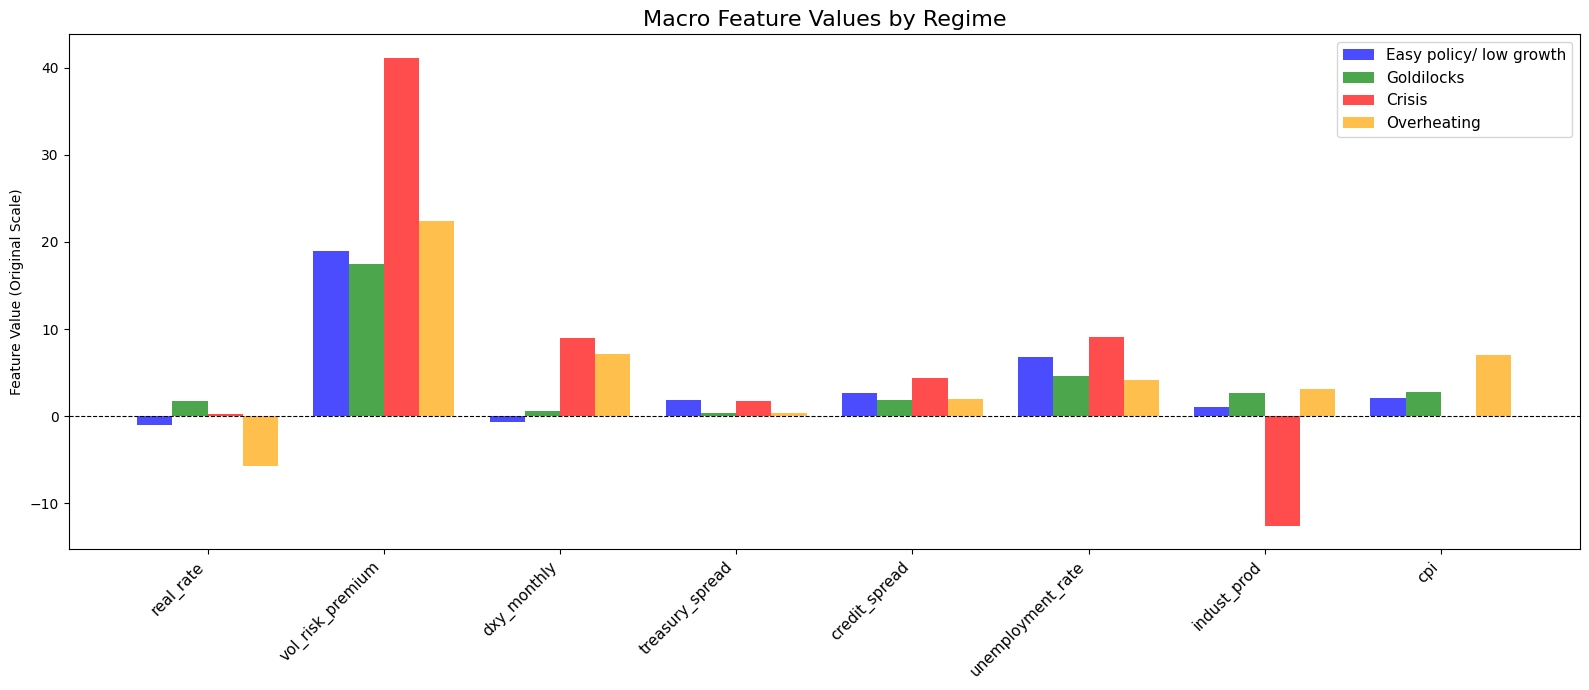

In [134]:
centroid_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.drop(['regime'], axis=1).columns,
    index=['Easy policy/ low growth', 'Goldilocks', 'Crisis', 'Overheating']
)

# Plot each feature as a grouped bar chart
features = centroid_df.columns
n_features = len(features)
n_regimes = 4
x = np.arange(n_features)
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))

colors = ['blue', 'green', 'red', 'orange']
for i, (regime, color) in enumerate(zip(centroid_df.index, colors)):
    ax.bar(x + i * width, centroid_df.loc[regime], width, 
           label=regime, color=color, alpha=0.7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=11)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Macro Feature Values by Regime', fontsize=16)
ax.set_ylabel('Feature Value (Original Scale)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

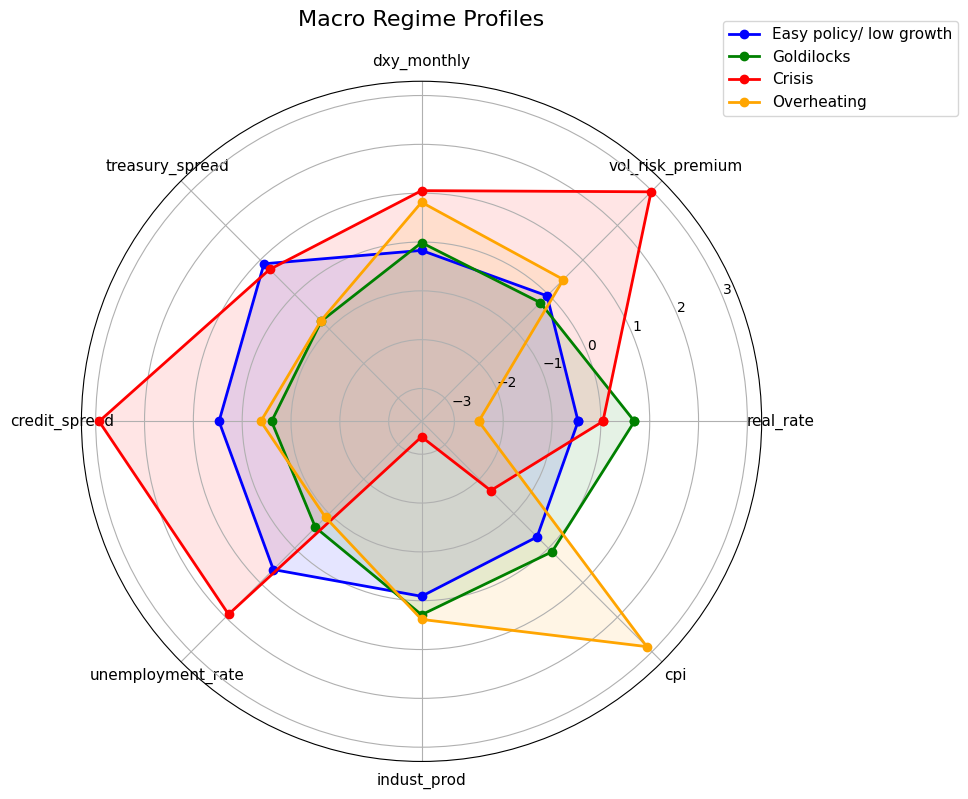

In [137]:

from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np

# Use scaled centroids for radar — puts everything on same scale
centroid_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.drop(['regime'], axis=1).columns,
    index=['Easy policy/ low growth', 'Goldilocks', 'Crisis', 'Overheating']
)

features = list(centroid_scaled.columns)
n_features = len(features)

# Compute angle for each feature
angles = [n / float(n_features) * 2 * np.pi for n in range(n_features)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = {'Easy policy/ low growth': 'blue', 'Goldilocks': 'green', 
          'Crisis': 'red', 'Overheating': 'orange'}

for regime, color in colors.items():
    values = centroid_scaled.loc[regime].tolist()
    values += values[:1]  # close the polygon
    ax.plot(angles, values, 'o-', linewidth=2, label=regime, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

# Add feature labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, size=11)
ax.set_title('Macro Regime Profiles', size=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.show()

In [138]:
regime_labels = {0: 'Easy policy/ low growth', 1: 'Goldilocks', 2: 'Crisis', 3: 'Overheating'}
df['regime_label'] = df['regime'].map(regime_labels)

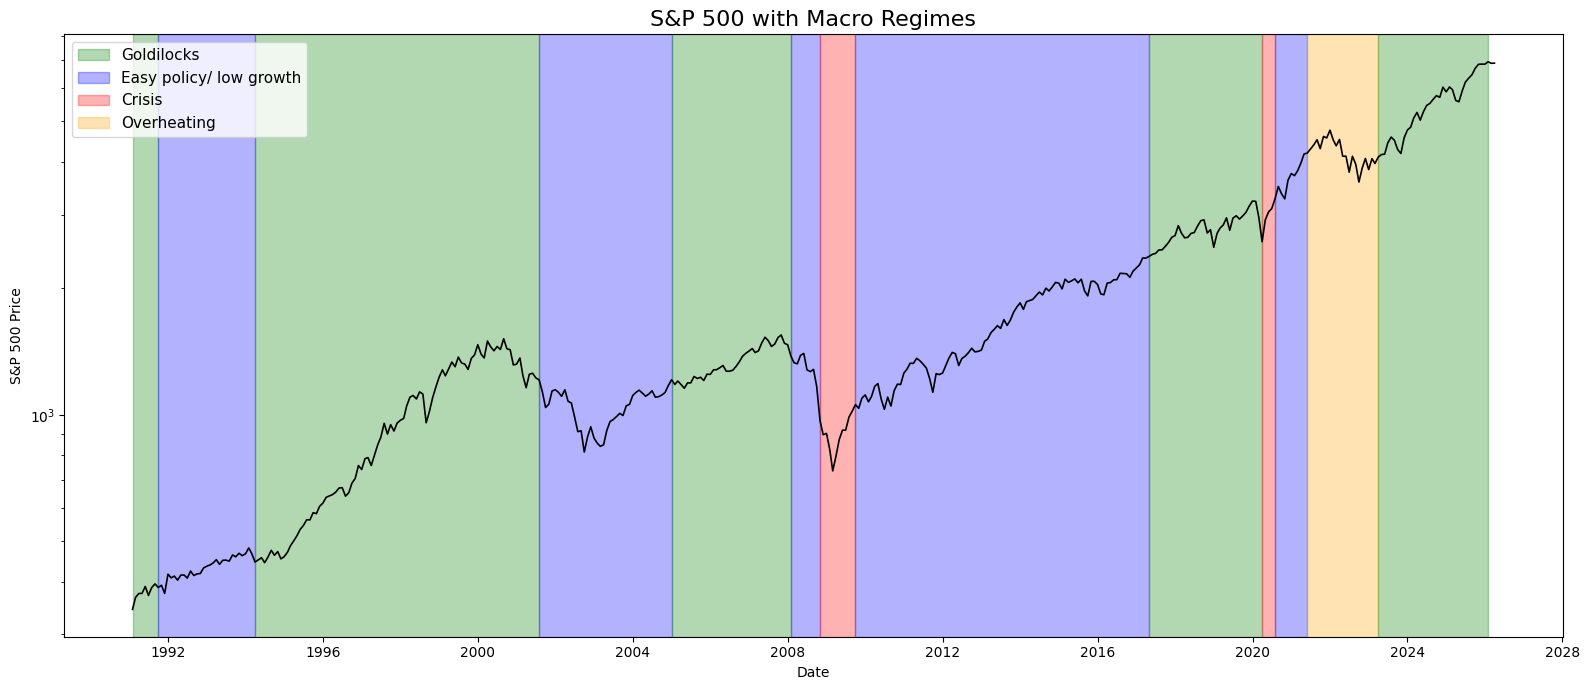

In [139]:
# Plotting regimes against S&P prices
# Pull S&P monthly prices for the visualization
sp500_monthly = sp500_daily['Close'].resample('ME').last()
sp500_monthly = sp500_monthly[sp500_monthly.index >= df.index[0]]

# Define colors for each regime
regime_colors = {
    'Goldilocks': 'green',
    'Easy policy/ low growth': 'blue',
    'Crisis': 'red',
    'Overheating': 'orange'
}

fig, ax = plt.subplots(figsize=(16, 7))

# Plot S&P 500
ax.plot(sp500_monthly.index, sp500_monthly.values, color='black', linewidth=1.2, zorder=5)

# Shade regime periods
current_regime = df['regime_label'].iloc[0]
start_date = df.index[0]

for i in range(1, len(df)):
    if df['regime_label'].iloc[i] != current_regime or i == len(df) - 1:
        ax.axvspan(
            start_date,
            df.index[i],
            alpha=0.3,
            color=regime_colors[current_regime],
            label=current_regime
        )
        current_regime = df['regime_label'].iloc[i]
        start_date = df.index[i]

# Clean up legend — remove duplicates
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=11)

ax.set_title('S&P 500 with Macro Regimes', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('S&P 500 Price')
ax.set_yscale('log')  # log scale so 1990s moves are visible alongside 2020s
plt.tight_layout()
plt.show()

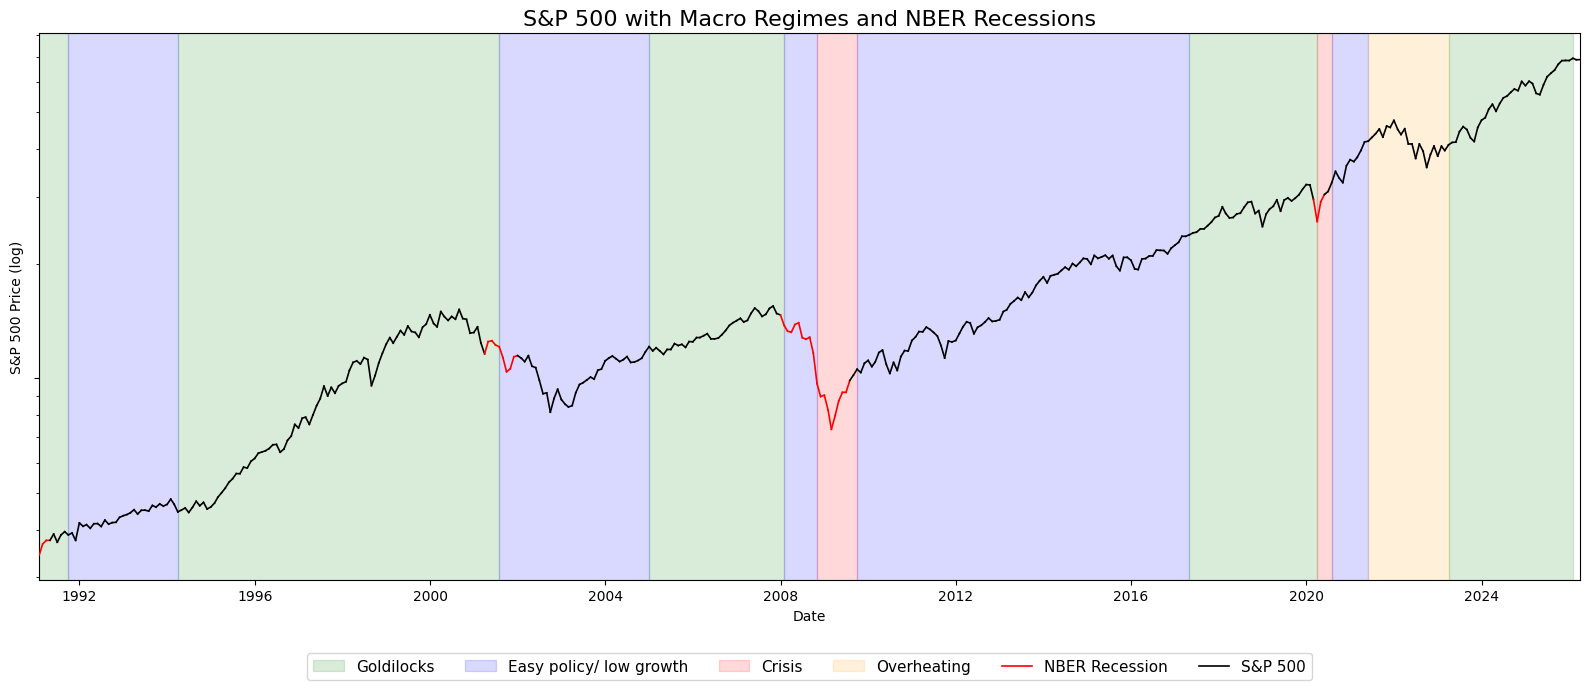

In [140]:
# adding the NBER recessions to see where the model tracks this
recessions = [
    ('1990-07-31', '1991-03-31'),
    ('2001-03-31', '2001-11-30'),
    ('2007-12-31', '2009-06-30'),
    ('2020-02-29', '2020-04-30')
]

regime_colors = {
    'Goldilocks': 'green',
    'Easy policy/ low growth': 'blue',
    'Crisis': 'red',
    'Overheating': 'orange'
}

fig, ax = plt.subplots(figsize=(16, 7))

# Shade regime periods
current_regime = df['regime_label'].iloc[0]
start_date = df.index[0]

for i in range(1, len(df)):
    if df['regime_label'].iloc[i] != current_regime or i == len(df) - 1:
        ax.axvspan(
            start_date,
            df.index[i],
            alpha=0.15,
            color=regime_colors[current_regime],
            label=current_regime
        )
        current_regime = df['regime_label'].iloc[i]
        start_date = df.index[i]

# Plot S&P 500 — different color during recessions
recession_periods = set()
for start, end in recessions:
    mask = (sp500_monthly.index >= start) & (sp500_monthly.index <= end)
    recession_periods.update(sp500_monthly.index[mask])

recession_label_added = False
normal_label_added = False

for i in range(len(sp500_monthly) - 1):
    x_vals = sp500_monthly.index[i:i+2]
    y_vals = sp500_monthly.values[i:i+2]
    in_recession = sp500_monthly.index[i] in recession_periods
    
    color = 'red' if in_recession else 'black'
    label = 'NBER Recession' if (in_recession and not recession_label_added) else \
            'S&P 500' if (not in_recession and not normal_label_added) else ''
    
    ax.plot(x_vals, y_vals, color=color, linewidth=1.2, zorder=5, label=label)
    
    if in_recession:
        recession_label_added = True
    else:
        normal_label_added = True

# Set x axis limits to data range exactly
ax.set_xlim(sp500_monthly.index[0], sp500_monthly.index[-1])

# Remove y ticks
ax.set_yticks([])
ax.set_yticklabels([])

# Legend below chart
handles, labels_list = ax.get_legend_handles_labels()
by_label = dict(zip(labels_list, handles))
ax.legend(by_label.values(), by_label.keys(), 
          loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=6, fontsize=11)

ax.set_title('S&P 500 with Macro Regimes and NBER Recessions', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('S&P 500 Price (log)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(plt.NullFormatter()) # removes all labels on y axis
plt.tight_layout()
plt.show()

## Validation via portfolio allocation

### Asset Returns

Now that 4 distinct macroeconomic regimes have been identified, we will consider how different asset classes perform under these regimes to make a recommendation of a suggested split.

In [141]:
# Asset classes
# sp500_monthly has already been attained
sp500_returns = sp500_daily['Close'].resample('ME').last().pct_change().squeeze()
sp500_returns.name = 'sp500'

# dxy_monthly has also already been attained
dxy_returns = dxy_monthly.pct_change()
dxy_returns.name = 'dxy'

# 20 yr treasury, starts from 2002
bonds_daily = yf.download('TLT', start='1990-01-01')
bonds_daily.columns = bonds_daily.columns.get_level_values(0)
bond_returns = bonds_daily['Close'].resample('ME').last().pct_change()
bond_returns.name = 'bonds'

# gold, starts from 2004
gold_daily = yf.download('GLD', start='1990-01-01')
gold_daily.columns = gold_daily.columns.get_level_values(0)
gold_returns = gold_daily['Close'].resample('ME').last().pct_change()
gold_returns.name = 'gold'

# high yield (hyg) from 2007
high_yield_daily = yf.download('HYD', start='1990-01-01')
high_yield_daily.columns = high_yield_daily.columns.get_level_values(0)
hy_returns = high_yield_daily['Close'].resample('ME').last().pct_change()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [142]:
print(type(sp500_returns))
print(type(bond_returns))
print(type(gold_returns))
print(type(hy_returns))
print(type(dxy_returns))

<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>


In [143]:
asset_returns = pd.DataFrame({
    'equities': sp500_returns,
    'bonds': bond_returns,
    'gold': gold_returns,
    'high_yield': hy_returns,
    'dollar': dxy_returns
})

# Align with regime labels
asset_returns['regime'] = df['regime_label']
# drop where regime has not been calculated (equities series starts 1 yr earlier)
asset_returns = asset_returns.dropna(subset=['regime'])

print(asset_returns.head())
print(asset_returns.shape)

            equities  bonds  gold  high_yield    dollar      regime
Date                                                               
1991-01-31  0.041518    NaN   NaN         NaN -0.012881  Goldilocks
1991-02-28  0.067281    NaN   NaN         NaN  0.025366  Goldilocks
1991-03-31  0.022203    NaN   NaN         NaN  0.094434  Goldilocks
1991-04-30  0.000320    NaN   NaN         NaN -0.005216  Goldilocks
1991-05-31  0.038605    NaN   NaN         NaN  0.017369  Goldilocks
(420, 6)


In [147]:
# getting the 3 month treasury bill for calculation as risk free rate in sharpe ratio
tbill = fred.get_series('TB3MS')

# this is an annualized number so need to convert to being monthly
tbill_monthly = tbill.resample('ME').last() / 100 / 12  
tbill_monthly.name = 'risk_free'

In [148]:
results = {}

for regime in asset_returns['regime'].unique():
    regime_data = asset_returns[asset_returns['regime'] == regime].drop('regime', axis=1)
    # DataFrame of monthly returns with one column per asset
    
    # Align risk free rate to regime months
    rf_regime = tbill_monthly.reindex(regime_data.index)
    
    mean_annual = regime_data.mean() * 12                    # annualized mean
    vol_annual = regime_data.std() * (12**0.5)               # annualized vol
    # Proper Sharpe — excess return over risk free
    excess_return = regime_data.subtract(rf_regime, axis=0)  # subtract rf from each row
    sharpe = (excess_return.mean() * 12) / vol_annual
    
    corr = regime_data.corr()                                 # correlation matrix
    
    results[regime] = {
        'mean_return': mean_annual,
        'volatility': vol_annual,
        'sharpe': sharpe,
        'correlation': corr
    }

In [149]:
# Summary table — mean return, vol, sharpe for each asset per regime
metrics = ['mean_return', 'volatility', 'sharpe']
metric_names = ['Mean Annual Return', 'Annual Volatility', 'Sharpe Ratio']

for metric, name in zip(metrics, metric_names):
    table = pd.DataFrame({
        # build a dictionary with regime as key and values as the different metric series across the assets
        regime: results[regime][metric] 
        for regime in results
        # when passing the dictionary into dataframe, pandas uses dictionary keys as column values and series indexes as the rows (label of
    }).round(3)
    print(f"\n{name}")
    print(table)

# Correlation matrices per regime
for regime in results:
    print(f"\nCorrelation Matrix — {regime}")
    print(results[regime]['correlation'].round(2))


Mean Annual Return
            Goldilocks  Easy policy/ low growth  Crisis  Overheating
equities         0.135                    0.078  -0.021       -0.010
bonds            0.062                    0.053   0.117       -0.135
gold             0.209                    0.046   0.201        0.023
high_yield       0.075                    0.070   0.078       -0.071
dollar           0.012                   -0.006  -0.012        0.079

Annual Volatility
            Goldilocks  Easy policy/ low growth  Crisis  Overheating
equities         0.130                    0.136   0.312        0.195
bonds            0.118                    0.129   0.242        0.159
gold             0.137                    0.186   0.243        0.145
high_yield       0.068                    0.075   0.270        0.097
dollar           0.071                    0.084   0.123        0.076

Sharpe Ratio
            Goldilocks  Easy policy/ low growth  Crisis  Overheating
equities         0.717                    0.496  -

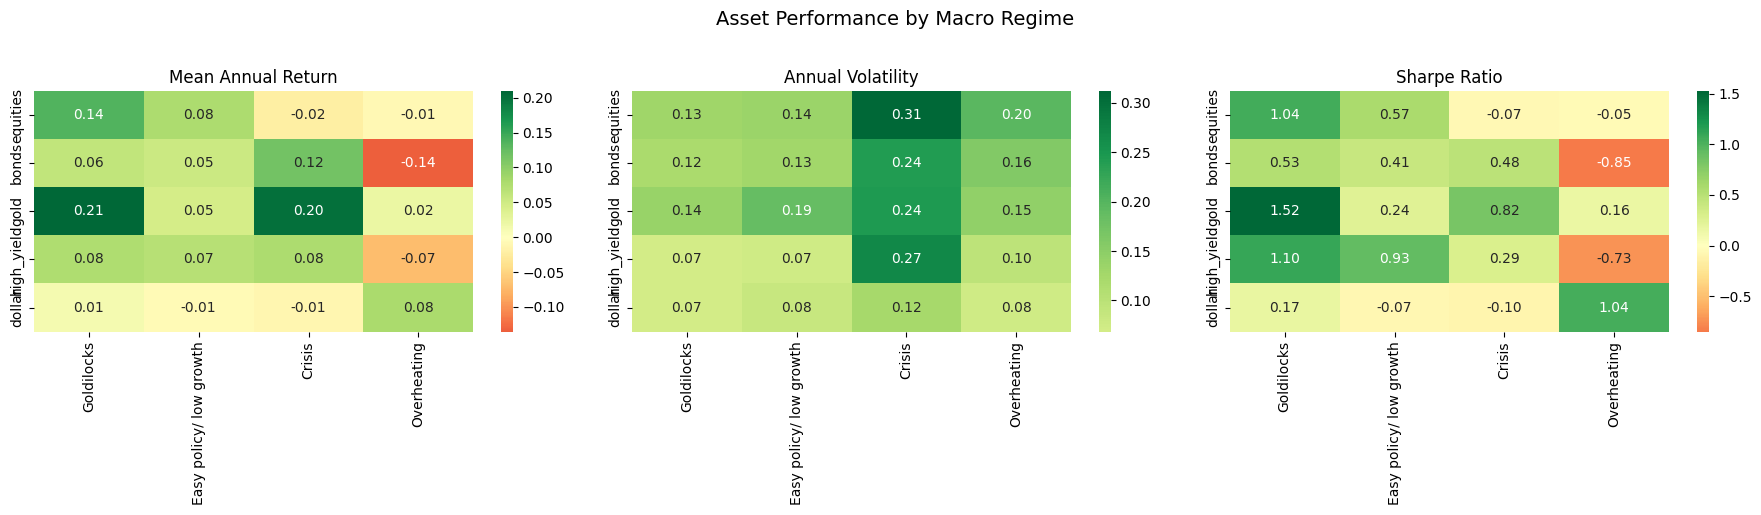

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, name in zip(axes, metrics, metric_names):
    table = pd.DataFrame({
        regime: results[regime][metric] 
        for regime in results
    })
    sns.heatmap(table, annot=True, fmt='.2f', cmap='RdYlGn', 
                center=0, ax=ax)
    ax.set_title(name, fontsize=12)

plt.suptitle('Asset Performance by Macro Regime', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

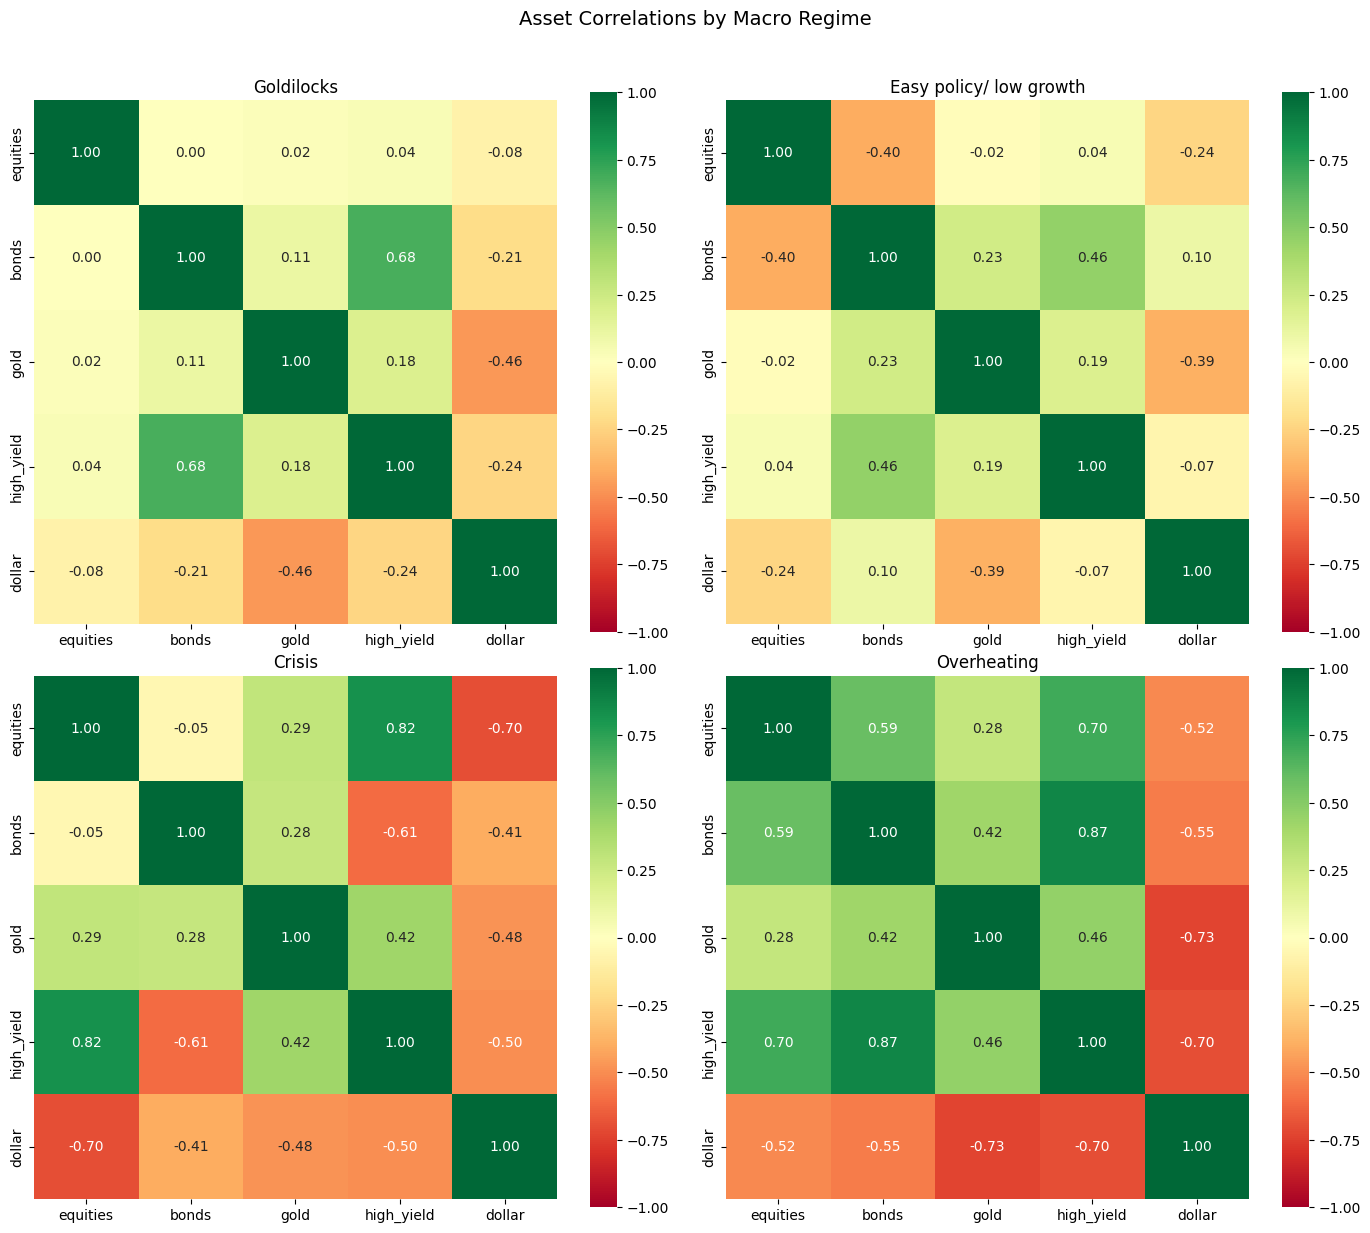

In [150]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

regimes = ['Goldilocks', 'Easy policy/ low growth', 'Crisis', 'Overheating']

for ax, regime in zip(axes, regimes):
    corr = results[regime]['correlation']
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, ax=ax,
                square=True)
    ax.set_title(regime, fontsize=12)

plt.suptitle('Asset Correlations by Macro Regime', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In the above, most interestingly traditional diversification breaks down in the 'overheating' regime, where we see equity and bonds have a posirivw correlation (in other times like crisis the relationship is negative as expected and in easy policy/ low growth it is also a negative correlation.

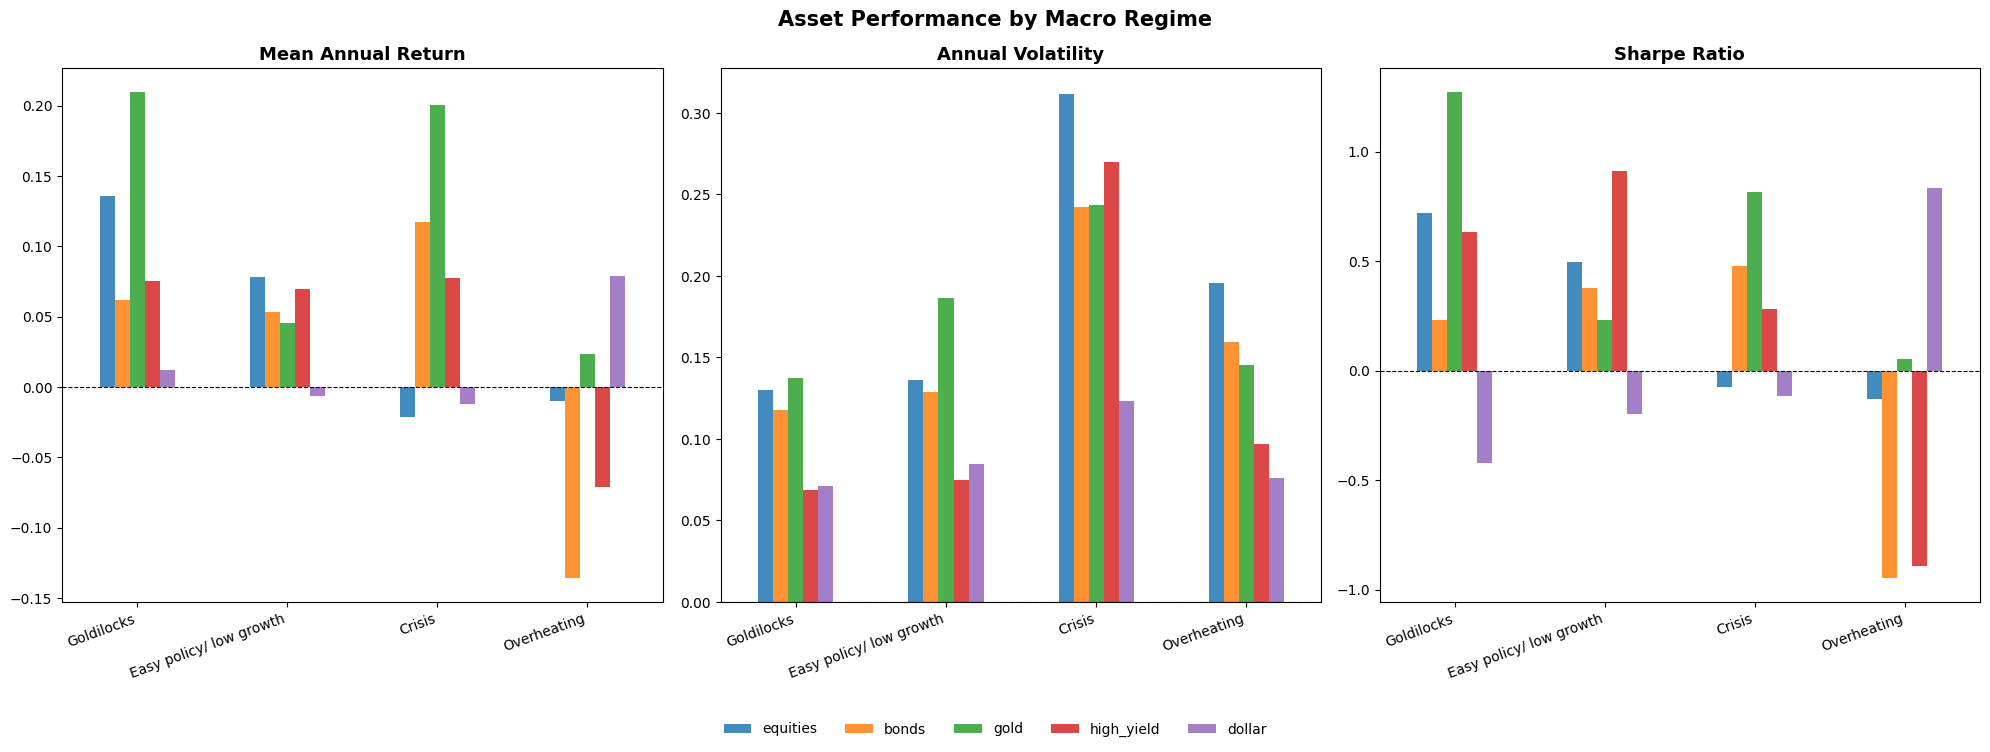

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, metric, name in zip(axes, metrics, metric_names):
    table = pd.DataFrame({
        regime: results[regime][metric]
        for regime in results
    })
    
    table.T.plot(kind='bar', ax=ax, alpha=0.85)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticklabels(table.columns, rotation=20, ha='right')
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.legend().set_visible(False)

# axes[2].legend(bbox_to_anchor=(1.05, 1), fontsize=10, frameon=False)
# Put a legend below current axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=5,
           fontsize=10,
           frameon=False)

plt.suptitle('Asset Performance by Macro Regime', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### TODO: add commentary on the above for different asset performances

### Asset Allocations

Using the historical returns of different regimes, I make different basket allocations for different macro regimes and see how these perform compared to other basket allocations.

#### Simple asset allocation by regime

In [178]:
allocations = {
    'Goldilocks': {
        'equities': 0.70,  
        'bonds': 0.10,
        'gold': 0.15,      
        'high_yield': 0.05,
        'dollar': 0.00
    },
    'Easy policy/ low growth': {
        'equities': 0.50,  
        'bonds': 0.20,
        'gold': 0.05,
        'high_yield': 0.25,
        'dollar': 0.00
    },
    'Crisis': {
        'equities': 0.05,
        'bonds': 0.35,
        'gold': 0.45,
        'high_yield': 0.05,
        'dollar': 0.10
    },
    'Overheating': {
        'equities': 0.15,
        'bonds': 0.05,
        'gold': 0.25,
        'high_yield': 0.10,
        'dollar': 0.45
    }
}

In [229]:
def sharpe_weighted_allocation(regime):
    sharpe = results[regime]['sharpe']
    positive = sharpe[sharpe > 0]
    weights = positive / positive.sum()
    return weights.to_dict()

allocations = {regime: sharpe_weighted_allocation(regime) 
               for regime in results}

In [230]:
# Assigned allocations for sharpe ratio
allocations = {regime: sharpe_weighted_allocation(regime) 
               for regime in results}

# Print weights for each regime
for regime, weights in allocations.items():
    print(f"\n{regime}")
    for asset, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
        print(f"  {asset:<15} {weight:.1%}")


Goldilocks
  gold            44.6%
  equities        25.2%
  high_yield      22.2%
  bonds           8.1%

Easy policy/ low growth
  high_yield      45.3%
  equities        24.6%
  bonds           18.7%
  gold            11.5%

Crisis
  gold            51.9%
  bonds           30.2%
  high_yield      17.9%

Overheating
  dollar          93.8%
  gold            6.2%


In [231]:
# Monthly portfolio return based on detected regime
portfolio_returns = []

for date, row in asset_returns.iterrows():
    regime = row['regime']
    if pd.isna(regime):
        continue
    
    alloc = allocations[regime]
    monthly_return = sum(
        alloc[asset] * row[asset]
        for asset in alloc
        if not pd.isna(row[asset])
    )
    portfolio_returns.append({'date': date, 'regime_portfolio': monthly_return})

portfolio_df = pd.DataFrame(portfolio_returns).set_index('date')

In [232]:
# 60% equities, 40% bonds — classic benchmark
portfolio_df['sixty_forty'] = (
    0.60 * asset_returns['equities'] +
    0.40 * asset_returns['bonds']
)

# Drop NaN rows — 60/40 only works where both assets have data
portfolio_df = portfolio_df.dropna()

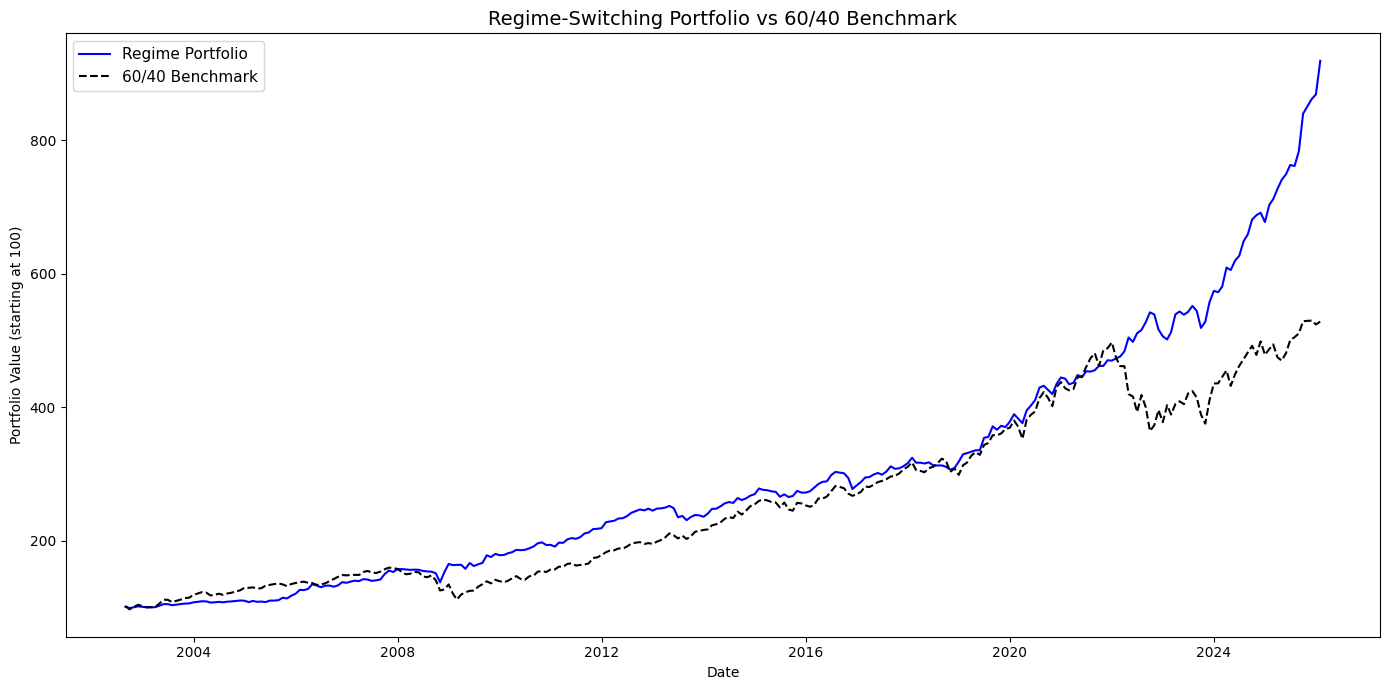

In [233]:
# Cumulative returns, start at 100
cumulative = (1 + portfolio_df).cumprod() * 100

plt.figure(figsize=(14, 7))
plt.plot(cumulative.index, cumulative['regime_portfolio'], 
         color='blue', linewidth=1.5, label='Regime Portfolio')
plt.plot(cumulative.index, cumulative['sixty_forty'], 
         color='black', linewidth=1.5, linestyle='--', label='60/40 Benchmark')

plt.title('Regime-Switching Portfolio vs 60/40 Benchmark', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (starting at 100)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [234]:
# Annualized metrics for both portfolios
for name, col in [('Regime Portfolio', 'regime_portfolio'), ('60/40', 'sixty_forty')]:
    ret = portfolio_df[col].mean() * 12
    vol = portfolio_df[col].std() * (12**0.5)
    sharpe = (portfolio_df[col].mean() - tbill_monthly.reindex(portfolio_df.index).mean()) * 12 / vol
    print(f"{name}: Return={ret:.2%}, Vol={vol:.2%}, Sharpe={sharpe:.2f}")

Regime Portfolio: Return=9.78%, Vol=7.41%, Sharpe=1.10
60/40: Return=7.62%, Vol=9.85%, Sharpe=0.60


## Backtesting

In [235]:
# To ensure there is no lookahead bias, we LAG by one regime
backtest_df = asset_returns.copy()
backtest_df['regime_lag'] = backtest_df['regime'].shift(1)
backtest_df = backtest_df.dropna()
# Dropping the original regime row
backtest_df = backtest_df.drop(columns=['regime'])

In [236]:
portfolio_returns_b = []

for date, row in backtest_df.iterrows():
    regime = row['regime_lag']
    if pd.isna(regime):
        continue
    
    alloc = allocations[regime]
    monthly_return = sum(
        alloc[asset] * row[asset]
        for asset in alloc
        if not pd.isna(row[asset])
    )
    portfolio_returns_b.append({'date': date, 'regime_portfolio': monthly_return})

portfolio_b_df = pd.DataFrame(portfolio_returns_b).set_index('date')

# 60/40 benchmark — also from backtest_df not asset_returns
portfolio_b_df['sixty_forty'] = (
    0.60 * backtest_df['equities'] +
    0.40 * backtest_df['bonds']
)

portfolio_b_df = portfolio_b_df.dropna()

In [237]:
# 60% equities, 40% bonds — classic benchmark
portfolio_b_df['sixty_forty'] = (
    0.60 * asset_returns['equities'] +
    0.40 * asset_returns['bonds']
)

# Drop NaN rows — 60/40 only works where both assets have data
portfolio_b_df = portfolio_b_df.dropna()

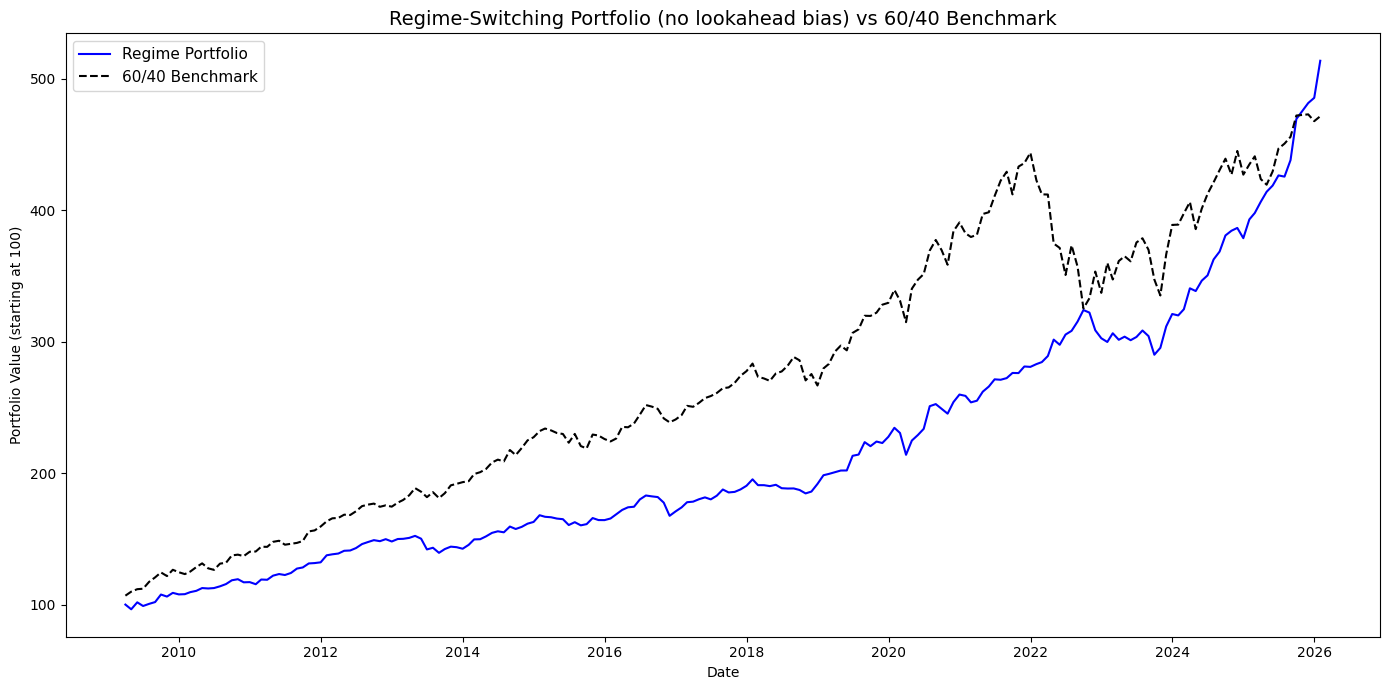

In [238]:
# Cumulative returns, start at 100
cumulative = (1 + portfolio_b_df).cumprod() * 100

plt.figure(figsize=(14, 7))
plt.plot(cumulative.index, cumulative['regime_portfolio'], 
         color='blue', linewidth=1.5, label='Regime Portfolio')
plt.plot(cumulative.index, cumulative['sixty_forty'], 
         color='black', linewidth=1.5, linestyle='--', label='60/40 Benchmark')

plt.title('Regime-Switching Portfolio (no lookahead bias) vs 60/40 Benchmark', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (starting at 100)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [239]:
# Annualized metrics for both portfolios
for name, col in [('Regime Portfolio', 'regime_portfolio'), ('60/40', 'sixty_forty')]:
    ret = portfolio_b_df[col].mean() * 12
    vol = portfolio_b_df[col].std() * (12**0.5)
    sharpe = (portfolio_b_df[col].mean() - tbill_monthly.reindex(portfolio_b_df.index).mean()) * 12 / vol
    print(f"{name}: Return={ret:.2%}, Vol={vol:.2%}, Sharpe={sharpe:.2f}")

Regime Portfolio: Return=10.02%, Vol=7.25%, Sharpe=1.20
60/40: Return=9.72%, Vol=9.77%, Sharpe=0.86


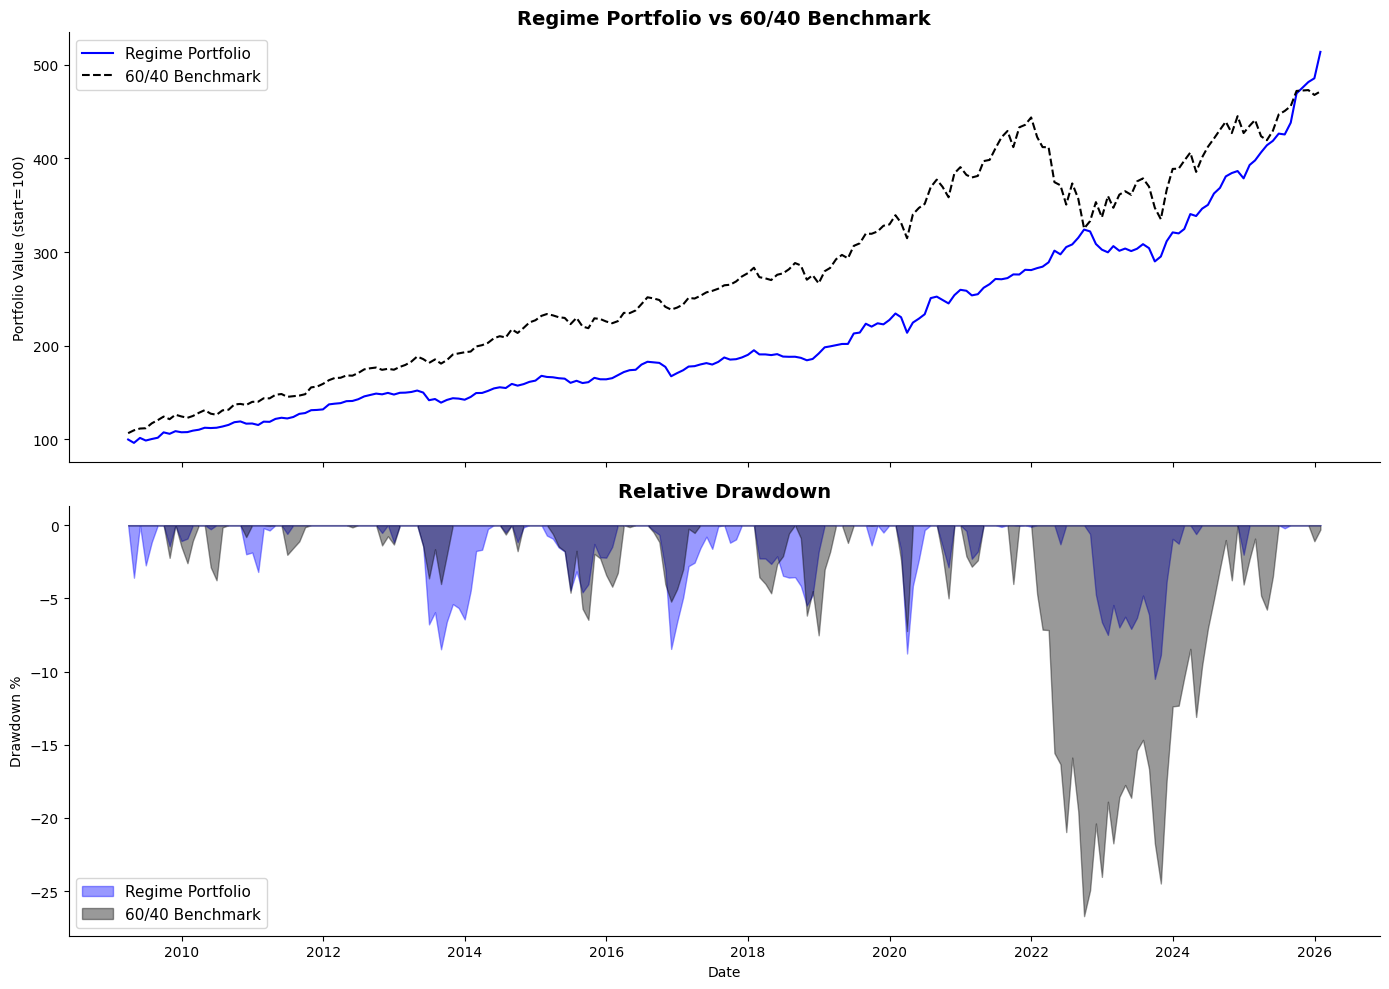

Regime Portfolio max drawdown: -10.50%
60/40 max drawdown:            -26.71%


In [240]:
def compute_drawdown(returns_series):
    cumulative = (1 + returns_series).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max * 100
    return drawdown

regime_dd = compute_drawdown(portfolio_b_df['regime_portfolio'])
sixty_forty_dd = compute_drawdown(portfolio_b_df['sixty_forty'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top — cumulative returns
cumulative = (1 + portfolio_b_df).cumprod() * 100
axes[0].plot(cumulative.index, cumulative['regime_portfolio'], 
             color='blue', linewidth=1.5, label='Regime Portfolio')
axes[0].plot(cumulative.index, cumulative['sixty_forty'], 
             color='black', linewidth=1.5, linestyle='--', label='60/40 Benchmark')
axes[0].set_ylabel('Portfolio Value (start=100)')
axes[0].set_title('Regime Portfolio vs 60/40 Benchmark', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Bottom — drawdowns
axes[1].fill_between(regime_dd.index, regime_dd, 0, 
                     alpha=0.4, color='blue', label='Regime Portfolio')
axes[1].fill_between(sixty_forty_dd.index, sixty_forty_dd, 0, 
                     alpha=0.4, color='black', label='60/40 Benchmark')
axes[1].set_ylabel('Drawdown %')
axes[1].set_xlabel('Date')
axes[1].set_title('Relative Drawdown', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print max drawdown for each
print(f"Regime Portfolio max drawdown: {regime_dd.min():.2f}%")
print(f"60/40 max drawdown:            {sixty_forty_dd.min():.2f}%")

Allocations are derived purely from regime-conditional Sharpe ratios; assets with negative Sharpe in a given regime receive zero weight. This produces concentrated positions in extreme regimes (e.g. 94% dollar in Overheating) which is intentionally aggressive: the purpose is to illustrate the signal, not construct a deployable portfolio. In practice, position limits and transaction costs would be applied.

## Validate with PCA

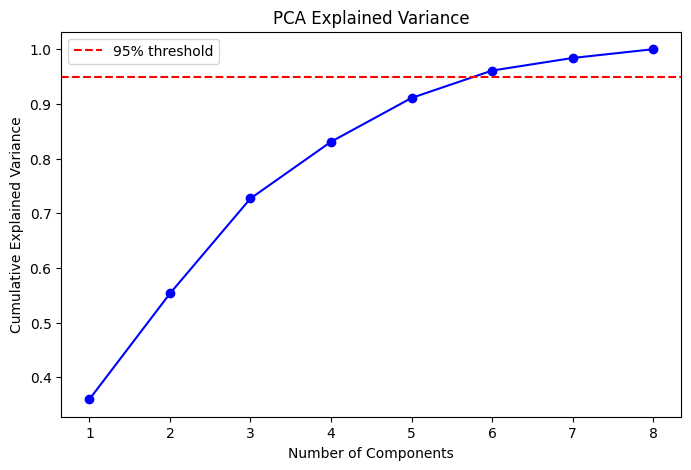

Components needed for 95% variance: 6


In [241]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_scaled)

explained_variance = pca.explained_variance_ratio_.cumsum()

# plotting the variance explained by each component
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

n_components = (explained_variance >= 0.95).argmax() + 1
print(f"Components needed for 95% variance: {n_components}")

6 components are able to explain 95% of the variance so a large proportion can be explained by out of the 8 features. Since PCA does not compress the variance into a very small number of components, it suggests the orignial features do not have enough correlation between one another to distort the K-means clustering.

In [243]:
# Fit PCA with 6 components
pca_final = PCA(n_components=6)
df_pca = pca_final.fit_transform(df_scaled)

# Rerun k-means on PCA components
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
pca_labels = kmeans_pca.fit_predict(df_pca)

# Compare assignments
df['regime_pca'] = pca_labels

# Agreement rate
agreement = (df['regime'] == df['regime_pca']).mean()
print(f"Agreement rate: {agreement:.1%}")

Agreement rate: 0.0%


Adjusted Rand Score: 1.000


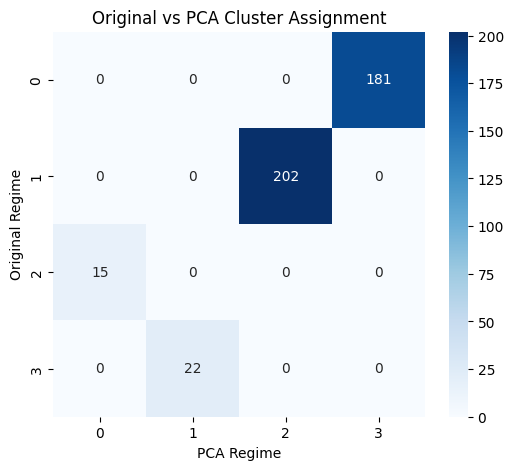

In [244]:
from sklearn.metrics import adjusted_rand_score

# Adjusted Rand Score — measures cluster similarity regardless of label numbering
# 1.0 = identical clustering, 0.0 = random, can be negative
ari = adjusted_rand_score(df['regime'], df['regime_pca'])
print(f"Adjusted Rand Score: {ari:.3f}")

# Also plot confusion matrix to see how labels map
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(df['regime'], df['regime_pca'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('PCA Regime')
plt.ylabel('Original Regime')
plt.title('Original vs PCA Cluster Assignment')
plt.show()

The Adjusted Rand Score of 1.0 indicates perfect agreement between the original and PCA-based clustering and every month receives the same regime assignment regardless of whether raw correlated features or orthogonalised PCA components are used. This confirms the four regimes represent genuine macro structure rather than artifacts of feature correlation.